In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('fraud_oracle.csv')
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [4]:
df.shape

(15420, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [6]:
df.columns.tolist()

['Month',
 'WeekOfMonth',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'WeekOfMonthClaimed',
 'Sex',
 'MaritalStatus',
 'Age',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'FraudFound_P',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'Year',
 'BasePolicy']

In [7]:
df.nunique().sort_values()

,0
AccidentArea,2
FraudFound_P,2
Fault,2
Sex,2
AgentType,2
PoliceReportFiled,2
WitnessPresent,2
VehicleCategory,3
Year,3
BasePolicy,3


In [8]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [9]:
target_counts = df['FraudFound_P'].value_counts()
target_share = target_counts / len(df) * 100
target_table = pd.DataFrame({'количество': target_counts, 'доля': target_share})
target_table

,количество,доля
FraudFound_P,,
0,14497,94.014267
1,923,5.985733


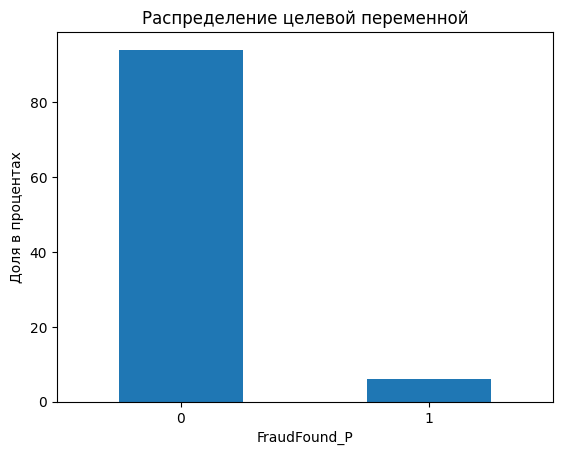

In [10]:
target_table['доля'].plot(kind='bar')
plt.title('Распределение целевой переменной')
plt.xlabel('FraudFound_P')
plt.ylabel('Доля в процентах')
plt.xticks(rotation=0)
plt.show()

In [11]:
df.isna().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['PolicyNumber'].duplicated().sum()

np.int64(0)

In [14]:
df.drop(columns=['PolicyNumber'])

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,Toyota,Urban,Tuesday,Nov,5,Male,Married,...,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1996,Collision
15416,Nov,5,Thursday,Pontiac,Urban,Friday,Dec,1,Male,Married,...,6 years,31 to 35,No,No,External,more than 5,no change,3 to 4,1996,Liability
15417,Nov,5,Thursday,Toyota,Rural,Friday,Dec,1,Male,Single,...,5 years,26 to 30,No,No,External,1 to 2,no change,1 vehicle,1996,Collision
15418,Dec,1,Monday,Toyota,Urban,Thursday,Dec,2,Female,Married,...,2 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,All Perils


In [15]:
object_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(object_cols)
print(numeric_cols)

['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']


In [16]:
bad_values = {}
for col in object_cols:
    values = df[col].value_counts()
    if '0' in values.index:
        bad_values[col] = values.loc['0']
bad_values

{'DayOfWeekClaimed': np.int64(1), 'MonthClaimed': np.int64(1)}

In [17]:
df[['Age']].describe()

,Age
count,15420.000000
mean,39.855707
std,13.492377
min,0.000000
25%,31.000000
50%,38.000000
75%,48.000000
max,80.000000


In [18]:
(df['Age'] == 0).sum()

np.int64(320)

In [19]:
age_zero_mask = df['Age'] == 0
age_not_zero_mask = df['Age'] != 0

age_zero_table = pd.DataFrame({
    'группа': ['Age = 0', 'Age > 0', 'все данные'],
    'количество': [
        age_zero_mask.sum(),
        age_not_zero_mask.sum(),
        len(df)],
    'мошеннических случаев': [
        df.loc[age_zero_mask, 'FraudFound_P'].sum(),
        df.loc[age_not_zero_mask, 'FraudFound_P'].sum(),
        df['FraudFound_P'].sum()],
    'процент мошеннических': [
        df.loc[age_zero_mask, 'FraudFound_P'].mean() * 100,
        df.loc[age_not_zero_mask, 'FraudFound_P'].mean() * 100,
        df['FraudFound_P'].mean() * 100]
})

age_zero_table['процент мошеннических'] = age_zero_table['процент мошеннических'].round(2)
age_zero_table

,группа,количество,мошеннических случаев,процент мошеннических
0,Age = 0,320,31,9.69
1,Age > 0,15100,892,5.91
2,все данные,15420,923,5.99


In [20]:
df_clean = df.copy()
df_clean['Age'] = df_clean['Age'].replace(0, np.nan)
df_clean['DayOfWeekClaimed'] = df_clean['DayOfWeekClaimed'].replace('0', np.nan)
df_clean['MonthClaimed'] = df_clean['MonthClaimed'].replace('0', np.nan)

df_clean.isna().sum().sort_values(ascending=False).head(10)

,0
Age,320
DayOfWeekClaimed,1
MonthClaimed,1
Month,0
WeekOfMonth,0
AccidentArea,0
Make,0
WeekOfMonthClaimed,0
DayOfWeek,0
Sex,0


In [21]:
df_clean['Age'].describe()

,Age
count,15100.000000
mean,40.700331
std,12.309493
min,16.000000
25%,31.000000
50%,39.000000
75%,49.000000
max,80.000000


In [22]:
features_table = pd.DataFrame({
    'Признак': [
        'Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
        'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus',
        'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice',
        'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating',
        'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims',
        'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled',
        'WitnessPresent', 'AgentType', 'NumberOfSuppliments',
        'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy',
        'FraudFound_P'
    ],
    'Смысл': [
        'месяц ДТП', 'неделя месяца ДТП', 'день недели ДТП', 'марка авто',
        'район ДТП', 'день недели обращения', 'месяц обращения',
        'пол водителя', 'семейное положение', 'возраст водителя',
        'кто виноват', 'тип полиса', 'категория авто', 'цена авто',
        'номер полиса', 'номер представителя', 'франшиза',
        'рейтинг водителя', 'сколько дней полису до ДТП',
        'сколько дней от полиса до обращения', 'прошлые обращения',
        'возраст машины', 'возраст держателя полиса',
        'был ли полицейский отчет', 'были ли свидетели',
        'тип агента', 'количество дополнительных выплат',
        'смена адреса перед заявкой', 'количество машин',
        'год наблюдения', 'базовый тип полиса',
        'целевой признак мошенничества'
    ],
    'Тип для анализа': [
        'категориальный', 'порядковый', 'категориальный', 'категориальный',
        'категориальный', 'категориальный', 'категориальный',
        'категориальный', 'категориальный', 'числовой',
        'категориальный', 'категориальный', 'категориальный',
        'порядковый', 'технический', 'порядковый', 'числовой',
        'порядковый', 'порядковый', 'порядковый',
        'порядковый', 'порядковый', 'порядковый',
        'бинарный', 'бинарный', 'бинарный', 'порядковый',
        'порядковый', 'порядковый', 'временной',
        'категориальный', 'target'
    ]
})

features_table

,Признак,Смысл,Тип для анализа
0,Month,месяц ДТП,категориальный
1,WeekOfMonth,неделя месяца ДТП,порядковый
2,DayOfWeek,день недели ДТП,категориальный
3,Make,марка авто,категориальный
4,AccidentArea,район ДТП,категориальный
5,DayOfWeekClaimed,день недели обращения,категориальный
6,MonthClaimed,месяц обращения,категориальный
7,Sex,пол водителя,категориальный
8,MaritalStatus,семейное положение,категориальный
9,Age,возраст водителя,числовой


In [23]:
numeric_cols_clean = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols_clean

['WeekOfMonth',
 'WeekOfMonthClaimed',
 'Age',
 'FraudFound_P',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Year']

In [24]:
df_clean[numeric_cols_clean].describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15100.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,40.700331,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,12.309493,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,16.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,39.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,49.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


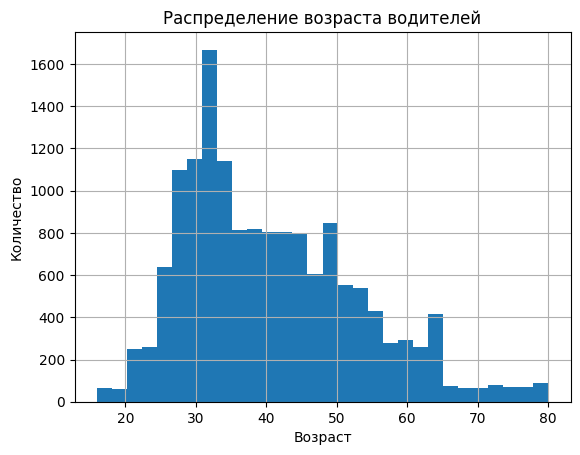

In [25]:
df_clean['Age'].hist(bins=30)

plt.title('Распределение возраста водителей')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

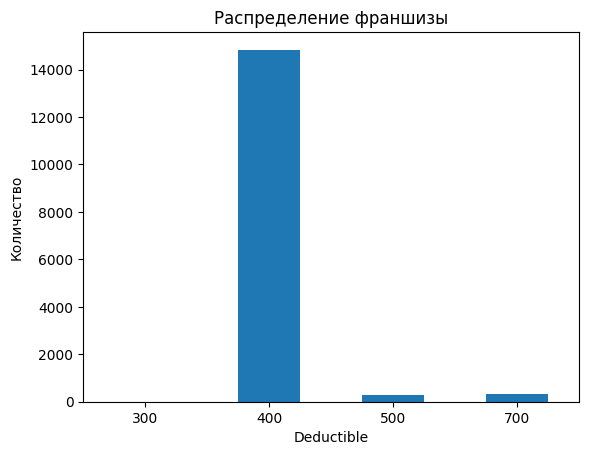

In [26]:
df_clean['Deductible'].value_counts().sort_index().plot(kind='bar')

plt.title('Распределение франшизы')
plt.xlabel('Deductible')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

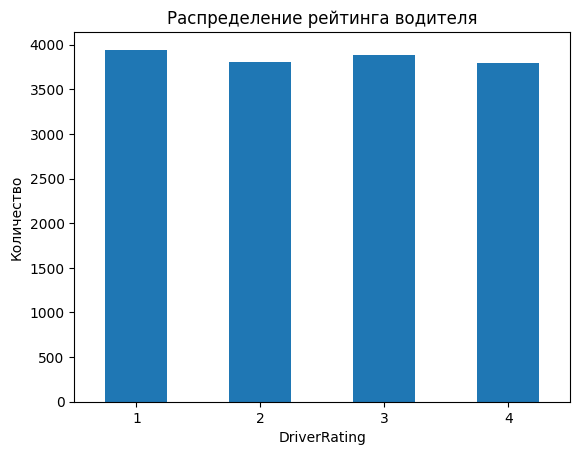

In [27]:
df_clean['DriverRating'].value_counts().sort_index().plot(kind='bar')

plt.title('Распределение рейтинга водителя')
plt.xlabel('DriverRating')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

In [28]:
df_clean['AccidentArea'].value_counts()

,count
AccidentArea,
Urban,13822
Rural,1598


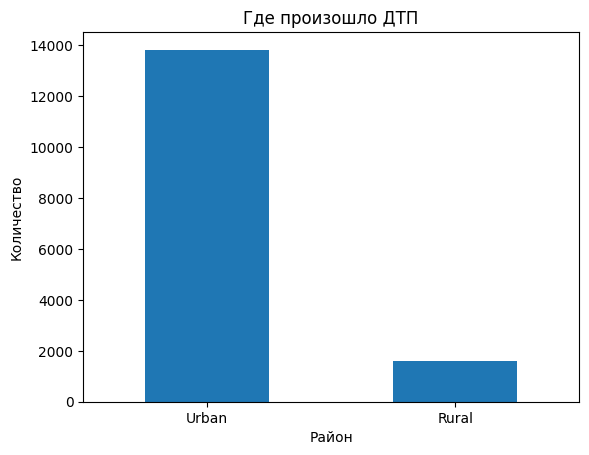

In [29]:
df_clean['AccidentArea'].value_counts().plot(kind='bar')

plt.title('Где произошло ДТП')
plt.xlabel('Район')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

In [30]:
df_clean['Fault'].value_counts()

,count
Fault,
Policy Holder,11230
Third Party,4190


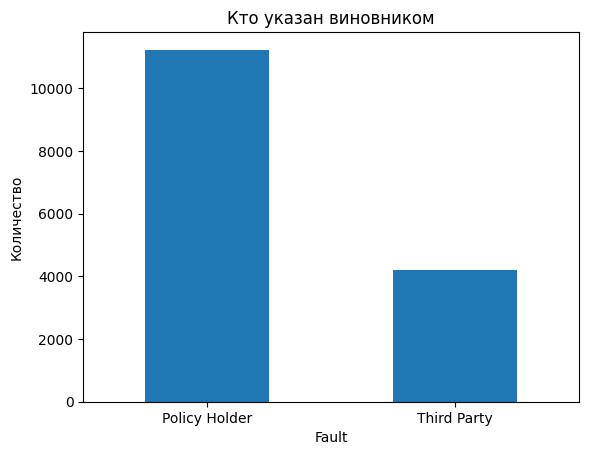

In [31]:
df_clean['Fault'].value_counts().plot(kind='bar')

plt.title('Кто указан виновником')
plt.xlabel('Fault')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

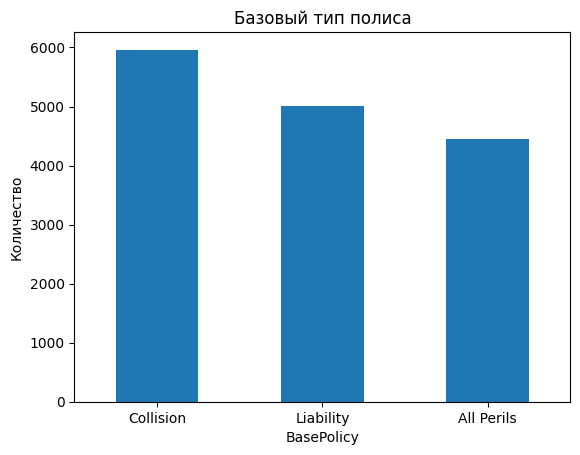

In [32]:
df_clean['BasePolicy'].value_counts().plot(kind='bar')

plt.title('Базовый тип полиса')
plt.xlabel('BasePolicy')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

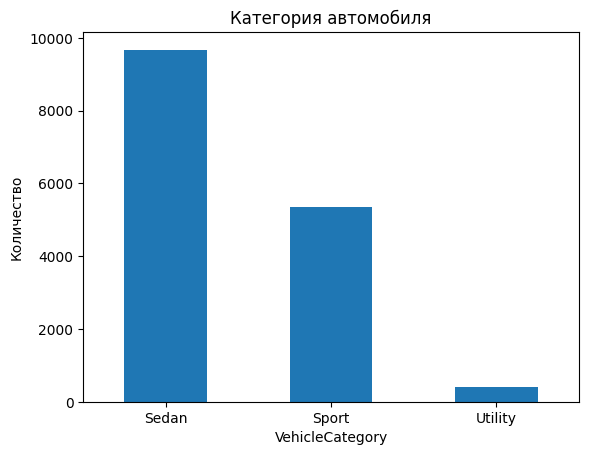

In [33]:
df_clean['VehicleCategory'].value_counts().plot(kind='bar')

plt.title('Категория автомобиля')
plt.xlabel('VehicleCategory')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

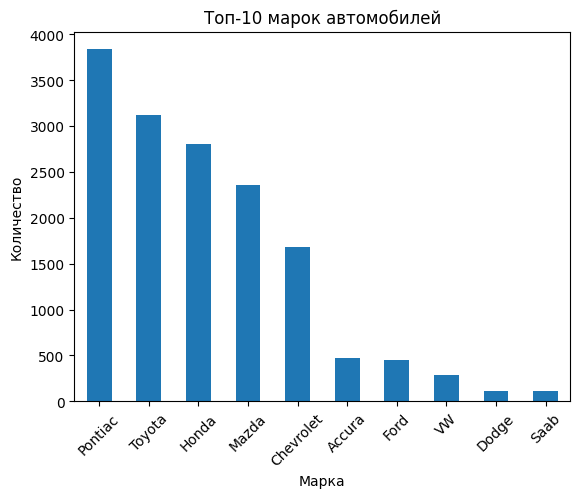

In [34]:
top_make = df_clean['Make'].value_counts().head(10)

top_make.plot(kind='bar')

plt.title('Топ-10 марок автомобилей')
plt.xlabel('Марка')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()